# Part 2: Find the optimal K using sklearn.cluster.kmeans for the Data06JoMix.csv and plot the elbow.

In [1]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline

In [9]:
# load dataframe 
df = pd.read_csv('Data06JoMix.csv')
df.head()

,Country,Age,Height_cm,Weight_kg,Sex,Weight_in_Words
0,USA,29,183.1,78.7,Male,seventy-eight
1,USA,58,188.3,93.6,Female,ninety-three
2,USA,57,170.0,112.0,Male,one hundred and twelve
3,USA,24,194.4,93.8,Male,ninety-three
4,USA,49,185.5,113.5,Female,one hundred and thirteen


In [10]:
# select only numerical features 
df = df.drop(['Country', 'Sex', 'Weight_in_Words'], axis='columns')

df

,Age,Height_cm,Weight_kg
0,29,183.1,78.7
1,58,188.3,93.6
2,57,170.0,112.0
3,24,194.4,93.8
4,49,185.5,113.5
...,...,...,...
495,18,168.6,75.8
496,26,198.2,74.5
497,37,165.1,85.9
498,25,199.1,61.5


In [11]:
# scale data using min-max
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

In [13]:
# find optimal k 
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

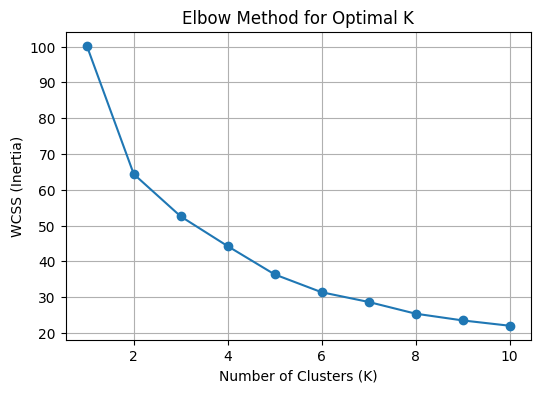

In [14]:
# plot the Elbow Curve
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

In [ ]:
# print WCSS values
for i, val in enumerate(wcss, start=1):
    print(f"K = {i}, WCSS = {val:.4f}")

K = 1, WCSS = 100.2212
K = 2, WCSS = 64.3718
K = 3, WCSS = 52.5550
K = 4, WCSS = 44.2518
K = 5, WCSS = 36.3597
K = 6, WCSS = 31.3825
K = 7, WCSS = 28.6713
K = 8, WCSS = 25.3988
K = 9, WCSS = 23.5179
K = 10, WCSS = 22.0338


### Given the Elbow plot and the data above, I would say, the optimal K is 4 or 5. 

In [ ]:
# create 4 clusters given k optimal is 4

kmeans = KMeans(n_clusters=4, )
y_kmeans = kmeans.fit_predict(df_scaled)

df['Cluster'] = y_kmeans

In [17]:
# print centroids 

print("Cluster Centers (scaled):")
print(kmeans.cluster_centers_)

Cluster Centers (scaled):
[[0.34669453 0.62534263 0.65758929]
 [0.17638561 0.34009141 0.32550835]
 [0.7515386  0.22439043 0.43567088]
 [0.73211753 0.61399549 0.28236695]]


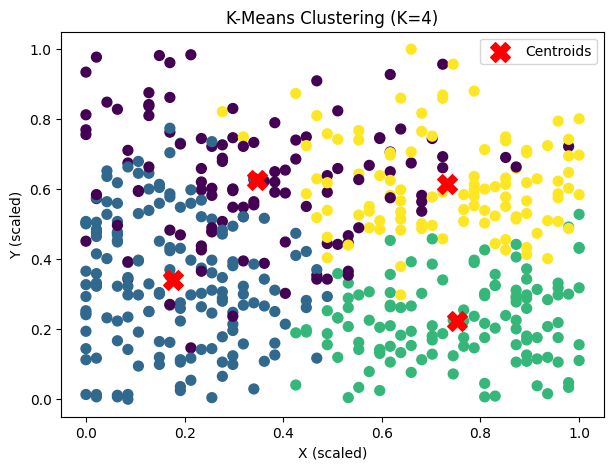

In [18]:
# Plot clusters
plt.figure(figsize=(7,5))
plt.scatter(df_scaled[:, 0], df_scaled[:, 1], c=y_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means Clustering (K=4)")
plt.xlabel("X (scaled)")
plt.ylabel("Y (scaled)")
plt.legend()
plt.show()